In [2]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [49]:
df.columns


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [51]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


DATA Cleaning

In [52]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicates

In [53]:
df=df.drop_duplicates()

Verification IF duplicates deleted or not 

In [54]:
df.shape

(9977, 13)

Now Data Trasformation - Creating a new column of Profit Margin % ( HOW MUCH PROFIT OF SALE , MEANS 1000RS sale have 200 rs profit that is 20% ), Loss Order ( USUALLY ANSWER IN TURE/FALSE , if loss order is yes profit is negative vise versa ) , High Value Order ( use to identify big price orders )

In [55]:
df["Profit Margine %"]=(df["Profit"]/df["Sales"])*100

checking

In [56]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margine %
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25


Loss order

In [57]:
import numpy as np 

df["Loss Order"] = np.where(df["Profit"] < 0, "Yes","No")

checking

In [58]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margine %,Loss Order
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,No
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,No
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,No
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,Yes
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,No


High Order Value

In [59]:
df["High Value Order"] = np.where(df["Sales"] > 500 , "Yes","No")

checking


In [60]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margine %,Loss Order,High Value Order
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,No,No
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,No,Yes
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,No,No
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,Yes,Yes
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,No,No


KPI - KEY PERFORMANCE INDICATOR ( Business ke important numbers jo batate hai ki company kaise perform kr rahi hai ) LIKE - total sales ,total profit , total order, ye quility business ke health bata deta hai 

In [61]:
df["Sales"].sum()

np.float64(2296195.5903)

total sales = 2296195.5903

In [62]:
df["Profit"].sum()

np.float64(286241.42260000005)

Total Profit = 286241.42260000005

In [63]:
len(df)

9977

total orders = 9977

In [64]:
df["Sales"].mean()

np.float64(230.14890150345792)

average order value = 30.14890150345792

Overall Profit Margin. = 12.46589897695093

In [65]:
(df["Profit"].sum()/df["Sales"].sum())*100


np.float64(12.46589897695093)

CATERGORY ANALYSIS = Which category gain more no. of sales  /// We are not creating new column 

In [66]:
category_sales=(df.groupby("Category")["Sales"].sum())
category_sales

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64

In [67]:
category_profit = (df.groupby("Category")["Profit"].sum())
category_profit 

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

Maximum Sales - technology 
minimum sales - furniture 

REGION ANALYSIS 

In [68]:
region_profit=(df.groupby("Region")["Profit"].sum())
region_profit

Region
Central     39655.8752
East        91506.3092
South       46749.4303
West       108329.8079
Name: Profit, dtype: float64

Max Sales - west
min Sales - south 

SUB CATEGORY ANALYSIS 

In [69]:
sub_profit = (df.groupby("Sub-Category")["Profit"].sum().sort_values())
sub_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

highest loss sub- category - tables 
highest profit sub - category - copiers

CUSTOMER SEGMENTATION - Mtlb category of customer , 3 type ke hai - 1. consumer , 2. corporate 3.home office 

In [70]:
segment_sales = (df.groupby("Segment")["Sales"].sum())
segment_sales

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64

Most Valued Segment - Consumer 


Discount Analysis = zada discount dene se profit badh raha hai ya kam ho rha hai 

In [71]:
discount_profit = (df.groupby("Discount")["Profit"].mean())
discount_profit

Discount
0.00     67.024108
0.10     96.055074
0.15     27.288298
0.20     24.721217
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -102.116395
Name: Profit, dtype: float64

means= 50% discount mai company loss mai hai 

GRAPHICAL REPRESENTATION 

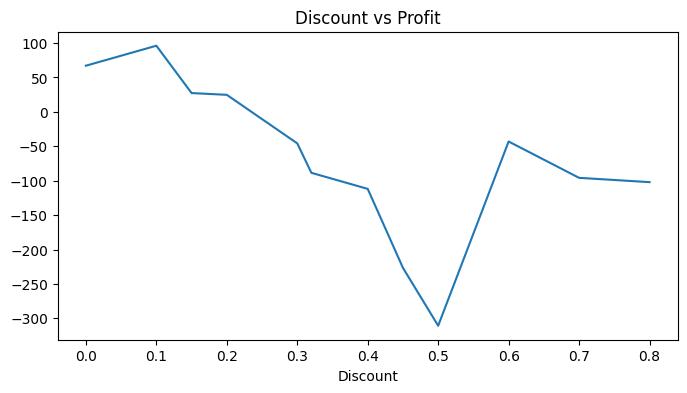

In [72]:
import matplotlib.pyplot as plt


discount_profit.plot(kind="line",figsize=(8,4))
plt.title("Discount vs Profit")

plt.show()

VISUALIZATION

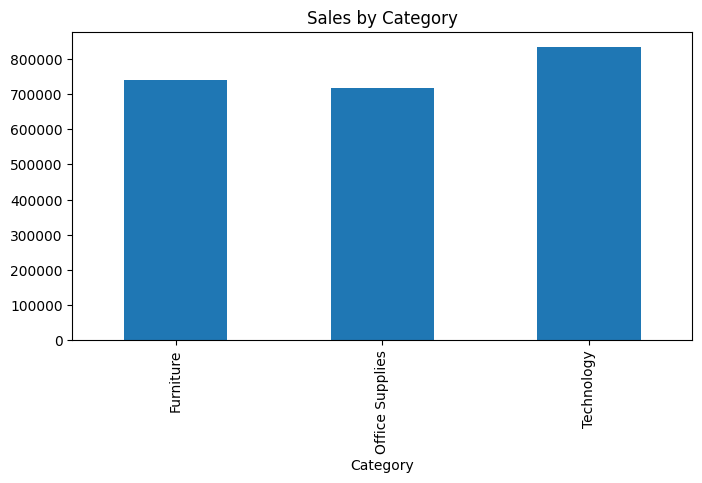

In [73]:
category_sales.plot(kind="bar",figsize=(8,4))
plt.title(
    "Sales by Category"
)
plt.savefig("charts/category_sales.png")
plt.show()

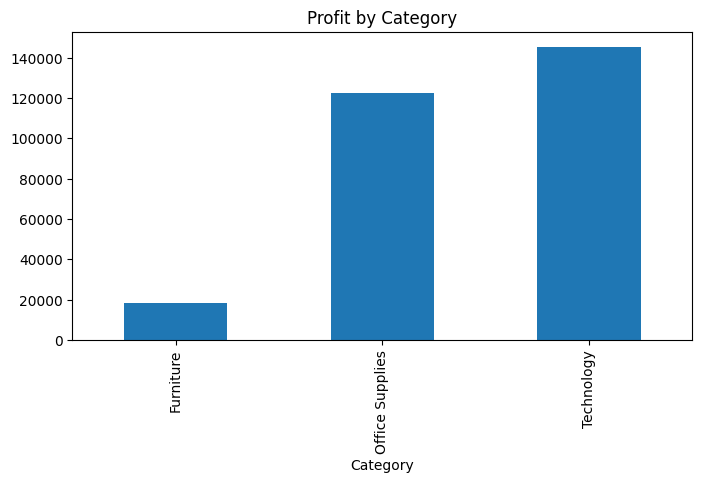

In [74]:
category_profit.plot(kind="bar",figsize=(8,4))
plt.title("Profit by Category")
plt.savefig("charts/category_profit.png")
plt.show()

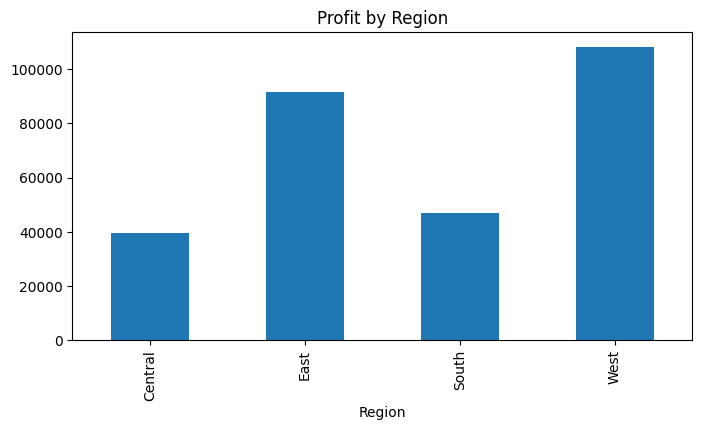

In [75]:
region_profit.plot(kind="bar",figsize=(8,4))
plt.title("Profit by Region")
plt.savefig("charts/category_region.png")
plt.show()

Export Cleaned Data

In [76]:
df.to_csv("cleaned_data/cleaned_superstore.csv",index=False)

# Final Business Insights

1. Highest sales category = (Technology)

2. Highest profit category = (Technology)

3. Most profitable region = (West)

4. Highest loss sub-category = (Tables)

5. High discounts negatively affect profit. 

6. Consumer segment contributes maximum sales. (Home Office)

# Project Summary

Objective:
To analyze Superstore sales data and identify opportunities to improve profitability and business performance.

Tasks Performed:

✓ Data Import
✓ Data Understanding
✓ Data Cleaning
✓ Data Transformation
✓ KPI Analysis
✓ Category Analysis
✓ Region Analysis
✓ Discount Analysis
✓ Customer Segment Analysis
✓ Loss Analysis
✓ Data Visualization
✓ Business Recommendations

Tools Used:

• Python
• Pandas
• NumPy
• Matplotlib
• Jupyter Notebook

Outcome:

The analysis identified Technology as the best-performing category, West as the most profitable region, and Tables as the highest loss-generating sub-category. Recommendations were provided to improve profitability and business growth.